# Fitting PPV with JAX/Optax from FITS files 
In this example we   
- load two PPV cubes in FITS format for p-NH2D and N2D+ starting from aribrary parameters (infall+rotation)    
- optimize the model starting from another set of initial parameters    
- plot results   

In [1]:
import jax.numpy as jnp
from vectorama.spectra import get_lines
from vectorama.observed import get_observed_ppv
from vectorama.optimizer import optimize
from vectorama.plots import plot_comparison


### Define loss threshold and velocity channels

In [2]:
# change this parameters depending on your GPU capabilities
loss_target = 1e-6  # target loss for optimization stopping criterion (1e-6 is usually good)
number_of_velocity_channels = 128 # number of velocity channels in the synthetic spectra (128 is usually good)

# velocity channels range ([-5, 5] covers most of the spectral features, but [-2, 2] works fine in this example)
velocity_channel_min = -2.0  # km/s
velocity_channel_max = 2.0  # km/s

### Load spectral data for the molecules

In [3]:
# define molecules to analyze
molecules = ["p-NH2D", "N2D+"]

# load line data for each molecule
vprof_neutral, Iprof_neutral, freq0_neutral = get_lines(molecules[0])
vprof_ion, Iprof_ion, freq0_ion = get_lines(molecules[1])

# define velocity channels for spectra
vchans = jnp.linspace(velocity_channel_min, velocity_channel_max, number_of_velocity_channels)

print("Spectral resolution (m/s): ", (vchans[1] - vchans[0])*1e3)

Spectral resolution (m/s):  31.496048


### Load observed PPV cubes from FITS files

In [4]:
ppv0, _ = get_observed_ppv("fits/ppv_target_NH2D.fits", freq0_neutral, vchans)
ppv1, _ = get_observed_ppv("fits/ppv_target_N2D+.fits", freq0_ion, vchans)

ppvs_target = jnp.stack([ppv0, ppv1], axis=0)

print("Observed PPV cubes shape: ", ppvs_target.shape)

Observed PPV cubes shape:  (2, 16, 16, 128)


### Set initial guess for model parameters

In [5]:
parameters_initial  = {
    'mff': 0.1,  # <<< Infall component
    'mrot': 0.1, # <<< Rotation component
    'xoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in x (plane of sky)
    'zoffset': jnp.array([0e0, 0e0]), # <<< Spatial offset in z (plane of sky)
    'vbulk': 0e0, # <<< Bulk velocity shift

    'v0': jnp.array([1e-4, 1e-4]), # <<< Velocity scaling of the Gaussian profile
    'r0_v': jnp.array([0.5, 0.5]), # <<< Center of the Gaussian velocity profile [0, 1]
    'sigma_v': jnp.array([0.05, 0.05]), # <<< Width of the Gaussian velocity profile

    'ngas0': jnp.array([1e0, 1e0]), # <<< Gas density scaling of the Gaussian profile
    'r0_ngas': jnp.array([0.1, 0.1]), # <<< Center of the Gaussian gas density profile [0, 1]
    'sigma_ngas': jnp.array([0.1, 0.1]), # <<< Width of the Gaussian gas density profile

    'sigma_turb': jnp.array([0.01, 0.01]), # <<< Microturbulent broadening
    'sigmadx': jnp.log10(jnp.array([0.1, 0.01])), # <<< Absorption coefficient scaling

    'theta0': 0e0, # <<< Yaw angle
    'theta1': 0e0, # <<< Pitch angle
    'theta2': 0e0, # <<< Roll angle
    'zratio': 1e0, # <<< Flattening of the core along the z axis

    'asym': jnp.array([0e0, 0e0]), # <<< Asymmetry scaling
    'asym_theta': jnp.array([0e0, 0e0]) # <<< Asymmetry angle
}

# bundle model arguments (spectral data)
model_args = {
    'Iprof': [Iprof_neutral, Iprof_ion],
    'vprof': [vprof_neutral, vprof_ion],
    'vchans': vchans
}

### Optimization

In [6]:
params_history = {k: [v] for k, v in parameters_initial.items()}

print("It takes a while to compile before starting optimization because JAX needs to compile the functions...")
parameters_optimized, ppvs_optimized, emission_optimized, models_optimized, params_history, loss_history = optimize(parameters_initial, ppvs_target, model_args,
                                                                                         learning_rate=1e-4, params_history=params_history,
                                                                                         loss_target=loss_target)

It takes a while to compile before starting optimization because JAX needs to compile the functions...


Loss: 1.009256e-06, Target: 1.000000e-06, Epoch: 18960: 100%|██████████| 100/100 [03:06<00:00,  1.86s/it]     


Converged at step 18968, Loss: 9.988571e-07 < 1.000000e-06


### Plot results to compare observed and optimized model

Velocity channel max 0.14173222
Max difference: 0.016133368


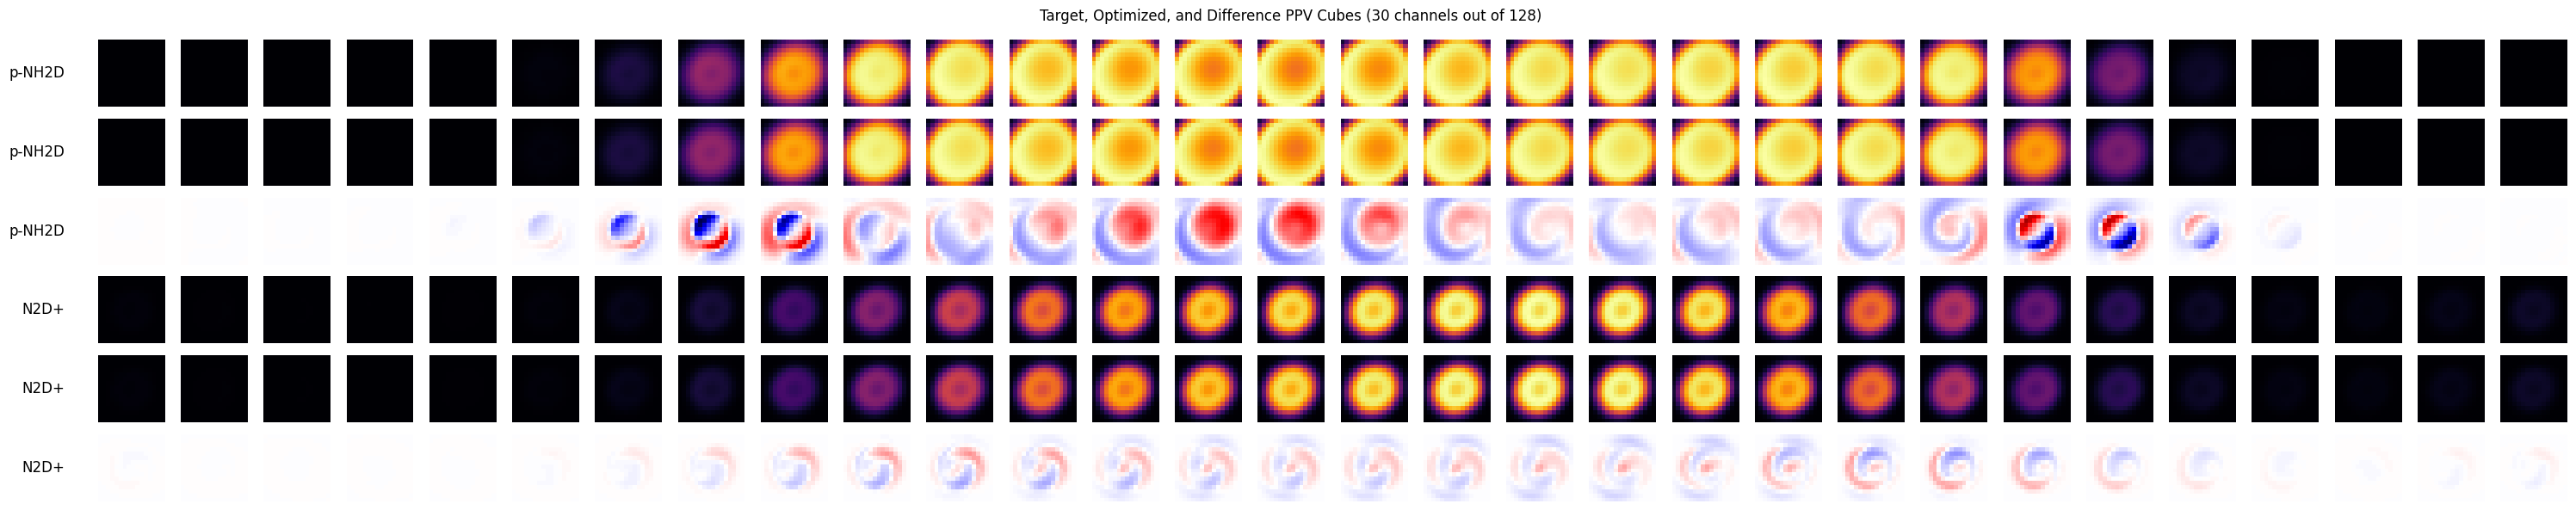

In [7]:
plot_comparison(ppvs_target, ppvs_optimized, vchans, molecules, nchans=30)
